In [88]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.utils.data as dataloader

# Vision Transformer for CIFAR-10

This notebook builds a simple Vision Transformer, or ViT, that learns to look at small pieces of an image and guess the picture class.

What the notebook does:
- loads the CIFAR-10 picture set
- cuts each image into patches
- turns patches into numbers the model can read
- sends the patch numbers through transformer blocks
- predicts the image class
- checks accuracy on the test set
- shows some example predictions

In [89]:
transform = transforms.Compose([transforms.ToTensor()])

## Step 1: Turn pictures into tensors

This block makes the images ready for the model. `ToTensor()` changes each picture into numbers the computer can use.

In [90]:
train_data = torchvision.datasets.CIFAR10(root = '../data', train = True, download = True, transform= transform)
val_data = torchvision.datasets.CIFAR10(root = '../data', train = False, download = True, transform= transform)

Files already downloaded and verified
Files already downloaded and verified


In [91]:
num_classes = 10
batch = 64
num_channels = 3
img_size = 32
patch_size = 8
num_patches = (img_size // patch_size) ** 2
embed_dim = 128
attention_heads = 8
transformer_layers = 4
mlp_hidden_nodes = 256
learning_rate = 1e-3
epochs = 20

## Step 3: Set the model size

These numbers tell the model how big each part should be, how many patches it sees, and how long it should train.

In [92]:
train_loader = dataloader.DataLoader(train_data, batch_size = batch, shuffle = True)
val_loader = dataloader.DataLoader(val_data, batch_size = batch, shuffle = False)

## Step 2: Make mini-batches

A `DataLoader` gives the model small groups of images at a time, instead of all pictures at once.

In [ ]:
# Patch embedding

# This layer cuts each image into small patches and turns each patch into numbers the model can read.
class PatchEmbedding(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(in_channels = num_channels, out_channels = embed_dim, kernel_size = patch_size, stride = patch_size)

    def forward(self, x):
        # Shape: [batch, channels, height, width] -> [batch, embed_dim, patch_h, patch_w]
        x = self.patch_embed(x)
        # Flatten the patch grid into a list of patch tokens.
        x = x.flatten(2)
        # Move the patch dimension into the middle so the transformer can read it.
        x = x.transpose(1, 2)
        return x


## Step 4: Turn each image into patches

This part chops every image into small square pieces. The model learns from these pieces instead of the whole picture at once.

In [ ]:
# Transformer encoder block

class TransformerEncoderBlock(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.multihead_attention = nn.MultiheadAttention(embed_dim = embed_dim, num_heads = attention_heads, batch_first = True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_nodes),
            nn.GELU(),
            nn.Linear(mlp_hidden_nodes, embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # Save the original input so the block can add it back later.
        residual1 = x
        x = self.norm1(x)
        # Attention helps each patch look at the other patches.
        x = self.multihead_attention(x, x, x)[0]
        x = x + residual1
        # Another skip connection keeps learning stable.
        residual2 = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = x + residual2
        return x
    
    

## Step 5: Let the model look at all patches

The transformer block helps the model compare patch pieces and learn which ones matter together.

In [ ]:
# MLP heads

class MLPHead(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        x = self.mlp_head(x)
        return x

## Step 6: Pick the class

The last small neural network turns the transformer output into one score for each class.

In [ ]:
class ViT(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding = PatchEmbedding()
        # The class token is a special extra token that stands for the whole image.
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Positional embedding tells the model where each patch came from.
        self.positional_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.transformer_encoders = nn.Sequential(*[TransformerEncoderBlock() for _ in range(transformer_layers)])
        self.mlp_head = MLPHead()

    def forward(self, x):
        x = self.patch_embedding(x)
        class_token = self.cls_token.expand(x.size(0), -1, -1)
        # Add the class token to the front of the patch list.
        x = torch.cat([class_token, x], dim=1)
        # Add position clues so the model knows patch order.
        x = x + self.positional_embedding
        x = self.transformer_encoders(x)
        # Use the class token output to make the final guess.
        x = x[:, 0]
        x = self.mlp_head(x)
        return x

## Step 7: Put all parts together

This cell builds the full ViT model. It connects patch making, the transformer blocks, and the final class guesser.

In [97]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ViT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)


## Step 8: Build the model and the optimizer

This part picks the computer the model will use, makes the ViT model, chooses the loss function, and sets up the optimizer for learning.

In [ ]:
# Training loop

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct_epoch = 0
    total_epoch = 0
    print(f"\nEpoch {epoch+1}")

    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move the images and labels to the same device as the model.
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim = 1)
        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        if batch_idx % 100 == 0:
            print(f" Batch {batch_idx+1 : 3d}: Loss = {loss.item(): .4f}, Accuracy = {accuracy:.2f}%")
        
    epoch_acc = 100.0 * correct_epoch / total_epoch
    print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")







Epoch 1
 Batch   1: Loss =  2.2853, Accuracy = 10.94%
 Batch  101: Loss =  2.0572, Accuracy = 26.56%
 Batch  201: Loss =  1.9988, Accuracy = 32.81%
 Batch  301: Loss =  1.8852, Accuracy = 28.12%
 Batch  401: Loss =  1.7415, Accuracy = 34.38%
 Batch  501: Loss =  1.2380, Accuracy = 51.56%
 Batch  601: Loss =  1.6751, Accuracy = 39.06%
 Batch  701: Loss =  1.4046, Accuracy = 53.12%
==> Epoch 1 Summary: Total Loss = 1427.7509, Accuracy = 31.62%

Epoch 2
 Batch   1: Loss =  1.5162, Accuracy = 39.06%
 Batch  101: Loss =  1.3414, Accuracy = 50.00%
 Batch  201: Loss =  1.3812, Accuracy = 43.75%
 Batch  301: Loss =  1.5277, Accuracy = 48.44%
 Batch  401: Loss =  1.3747, Accuracy = 37.50%
 Batch  501: Loss =  1.4993, Accuracy = 40.62%
 Batch  601: Loss =  1.7469, Accuracy = 32.81%
 Batch  701: Loss =  1.5231, Accuracy = 51.56%
==> Epoch 2 Summary: Total Loss = 1199.2797, Accuracy = 44.09%

Epoch 3
 Batch   1: Loss =  1.1254, Accuracy = 57.81%
 Batch  101: Loss =  1.6358, Accuracy = 43.75%
 Bat

## Step 9: Teach the model

This loop shows the model many images, checks how wrong it is, and slowly helps it get better.

In [99]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    val_accuracy = 100.0 * correct / total
    print(f"\nValidation Accuracy: {val_accuracy:.2f}%")


Validation Accuracy: 56.02%


## Step 10: Check accuracy

This block looks at the test images and tells us how often the model was right.

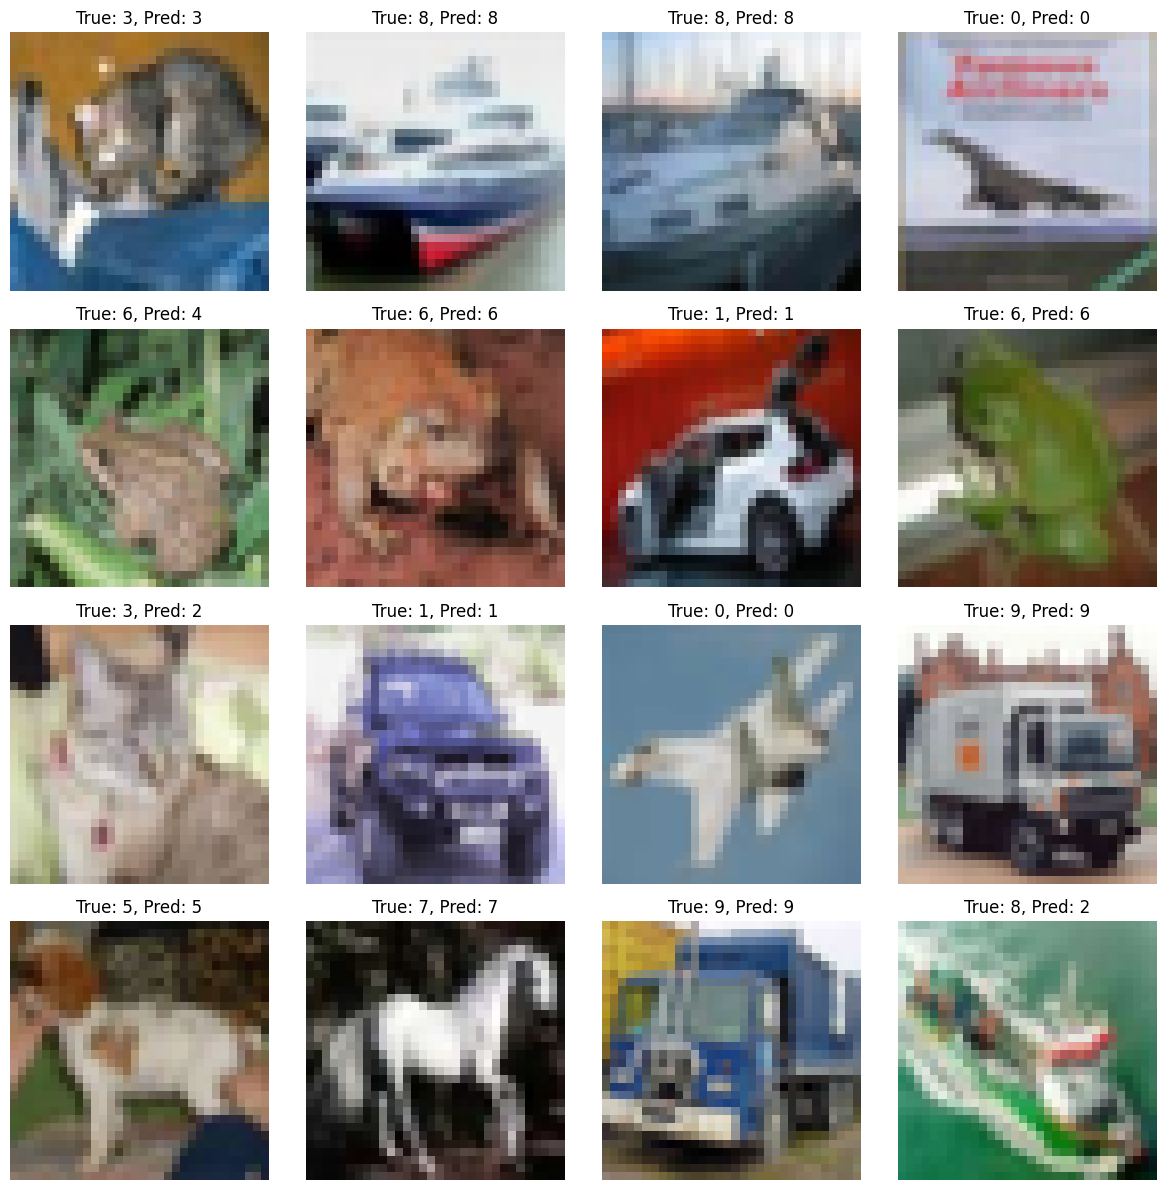

In [102]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    images, labels = next(iter(val_loader))
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    preds = outputs.argmax(dim=1)
    images = images.cpu()
    labels = labels.cpu()
    preds = preds.cpu()
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images[i].permute(1, 2, 0))
        ax.set_title(f"True: {labels[i].item()}, Pred: {preds[i].item()}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Step 11: Show some predictions

This picture grid lets us see the model's guesses next to the true answers.

In [101]:
# data_point, label = next(iter(train_loader))
# print(f"Data point shape: {data_point.shape}")

# patch_embed = nn.Conv2d(in_channels = num_channels, out_channels = embed_dim, kernel_size = patch_size, stride = patch_size)
# embedded_patches = patch_embed(data_point)
# print(f"Embedded patches shape: {embedded_patches.shape}")

# patch_embed_flattened = embedded_patches.flatten(2)
# print(f"Flattened embedded patches shape: {patch_embed_flattened.transpose(1, 2).shape}")